<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week11_%EC%84%B1%EB%8A%A5%EC%B5%9C%EC%A0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#하이퍼파라미터를 이용한 성능 최적화


 배치 정규화
 -정규회는 각 특성 범위(스케일(scalc) )를 조정한다는 의미로 특성 스케일링(featur‘e scalin상)이라고도
합니다.


-규제화{reguJarization)는 모텔 복잡도를 줄이기 위해 제약을 두는 방법입니다. 이때 제약은 데이터
가 네트워크에 들어가기 전에 필터를 적용한 것이라고 생각하면 됩니다.   
-> 드롭아웃， 조기 종료


-표준화  
z-스코어 정규화
라고도합니다.

-배치 정규화: 기울기 소멸이나 기울기 폭팔 등의 문제 해결/ 일반적으로 기울기 소멸이나 폭발 문제를 해결하기 위해 손실 함수로 렐
루(HcLU)를 시용하거나 초깃값 튜닝 학습률 조정                                                 
기울기 소멸, 폭발 원인: 네트워크 각 층마다 활성화 함수가 적용되면서 입력값들의 분포가 계속 바뀌는 현상-> 분산된 분포를 정규분포로 만들기 위해 표준화와 유사한 방식을 미니배치에 적용   

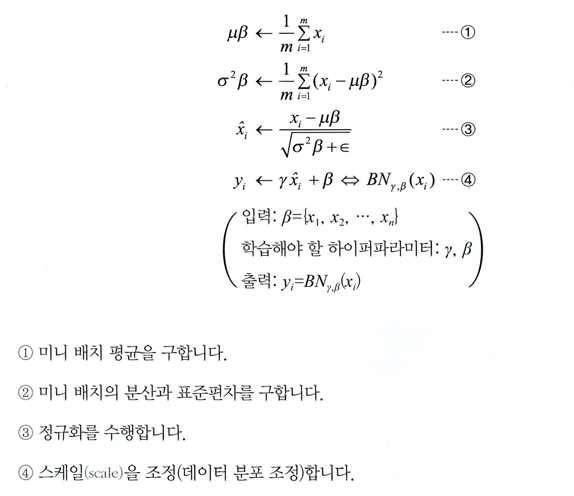

드롭아웃(dropout)이란 훈련할 때 일정 비율의 뉴런만 사용하고 나머지 뉴런에 해당하는 가중치
는 업데이트하지 않는 방법입니다. 물론 매 단계마다 사용하지 않는 뉴런을 바꾸어 가며 훈련시겁
니다. 즉， 드롭아웃은 노드를 임의로 끄면서 학습하는 방법으로， 은닉층에 배치된 노드 중 일부를
임의로 끄면서 학습합니다. 꺼진 노드는 신호를 전달하지 않으므로 지나친 학습을 방지하는 효과
가생겁니다.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

In [3]:
trainset=torchvision.datasets.FashionMNIST(
    root='/content/sample_data',train=True,download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 162kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.4MB/s]


In [5]:
batch_size=4
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)


In [7]:
dataiter=iter(trainloader)
images,labels=next(dataiter)
print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
6


In [8]:
def imshow(img,title):
  plt.figure(figsize=(10,10))
  img=img/2+0.5
  npimg=img.numpy()
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.title(title)
  plt.show()

In [9]:
def show_batch_images(dataloader):
  images,labels=next(iter(dataloader))
  img=torchvision.utils.make_grid(images)
  imshow(img,title=[str(x.item()) for x in labels])
  return images,labels

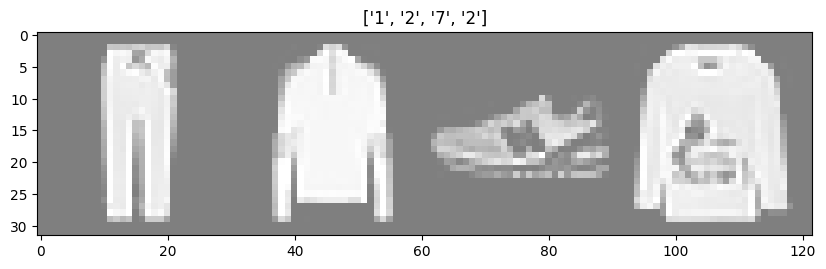

In [10]:
images,labels=show_batch_images(trainloader)

In [32]:
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet,self).__init__()
    self.classifier=nn.Sequential(
        nn.Linear(784,48),
        nn.ReLU(),
        nn.Linear(48,24),
        nn.ReLU(),
        nn.Linear(24,10)
    )
  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=self.classifier(x)
    return x

In [33]:
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet,self).__init__()
    self.classifier=nn.Sequential(
        nn.Linear(784,48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48,24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24,10)
    )
  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=self.classifier(x)
    return x

 배치 정규화는 완전언결층과 합성곱층 뒤
활성화 함수 앞에 위치한다

In [34]:
model=NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [35]:
model_bn=BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [36]:
batch_size=512
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)

In [37]:
loss_fn=nn.CrossEntropyLoss()
opt=optim.SGD(model.parameters(),lr=0.01)
opt_bn=optim.SGD(model_bn.parameters(),lr=0.01)

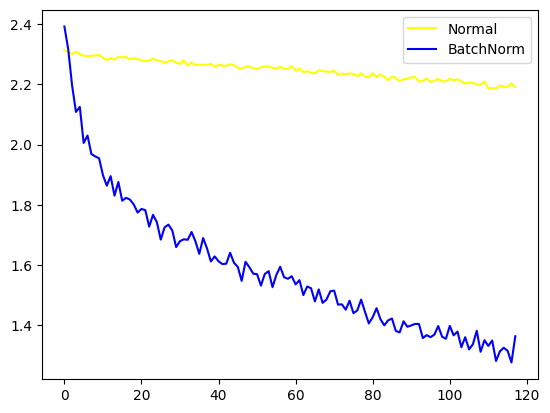

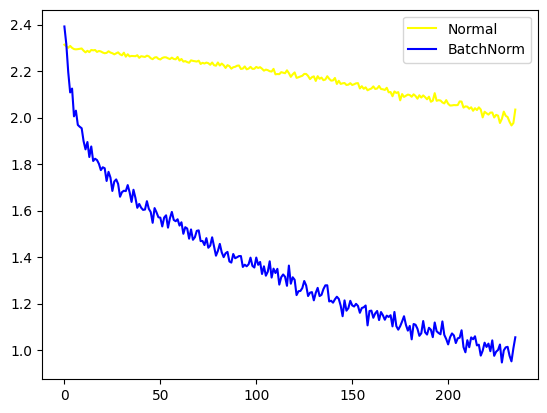

In [38]:
loss_arr=[]
loss_bn_arr=[]
max_epochs=2

for epoch in range(max_epochs):
  for i,data in enumerate(trainloader,0):
    inputs,labels=data
    opt.zero_grad()
    outputs=model(inputs)
    loss=loss_fn(outputs,labels)
    loss.backward()
    opt.step()
    opt_bn.zero_grad()
    outputs_bn=model_bn(inputs)
    loss_bn=loss_fn(outputs_bn,labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())
  plt.plot(loss_arr,'yellow',label='Normal')
  plt.plot(loss_bn_arr,'blue',label='BatchNorm')
  plt.legend()
  plt.show()

In [39]:
N=50
noise=0.3
x_train=torch.unsqueeze(torch.linspace(-1,1,N),1)
y_train=x_train+noise*torch.normal(torch.zeros(N,1),torch.ones(N,1))
x_test=torch.unsqueeze(torch.linspace(-1,1,N),1)
y_test=x_test+noise*torch.normal(torch.zeros(N,1),torch.ones(N,1))

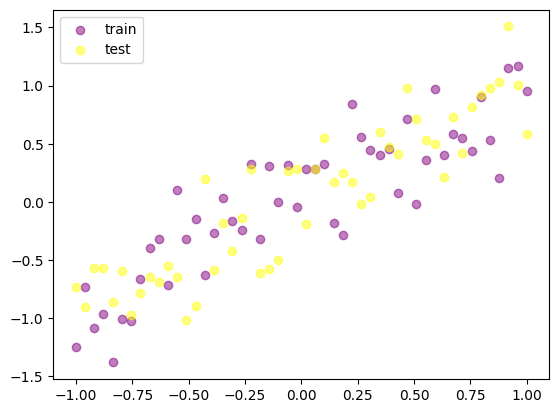

In [41]:
plt.scatter(x_train.data.numpy(),y_train.data.numpy(),c='purple',
            alpha=0.5,label='train')
plt.scatter(x_test.data.numpy(),y_test.data.numpy(),c='yellow',
            alpha=0.5,label='test')
plt.legend()
plt.show()

In [43]:
N_h=100
model=torch.nn.Sequential(
    torch.nn.Linear(1,N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,1)
)
model_dropout=torch.nn.Sequential(
    torch.nn.Linear(1,N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,1)
)

In [44]:
opt=torch.optim.Adam(model.parameters(),lr=0.01)
opt_dropout=torch.optim.Adam(model_dropout.parameters(),lr=0.01)
loss_fn=torch.nn.MSELoss()

/tmp/ipykernel_1680/3317045535.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d,Loss= %0.4f, Loss with droplout=%0.4f'%(epoch,test_loss,test_loss_dropout)  )


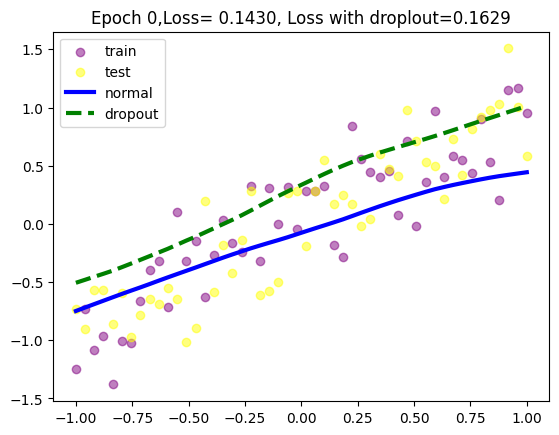

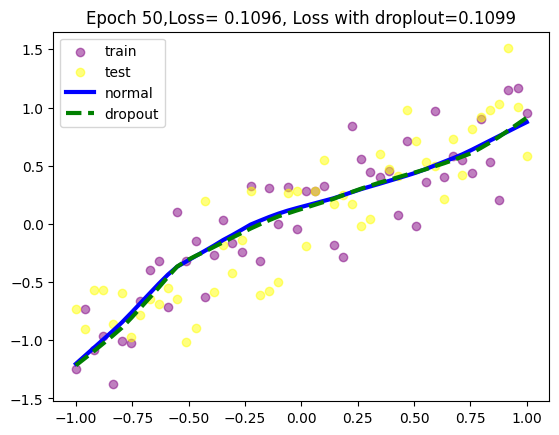

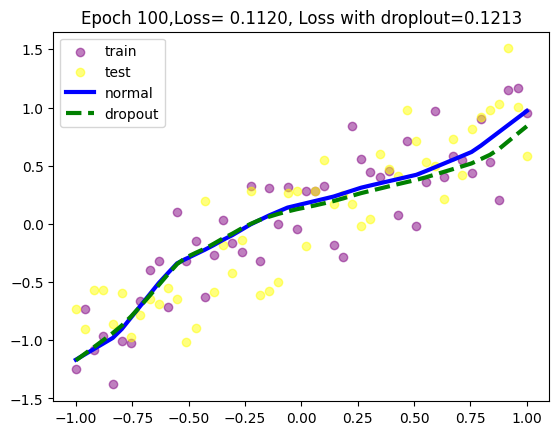

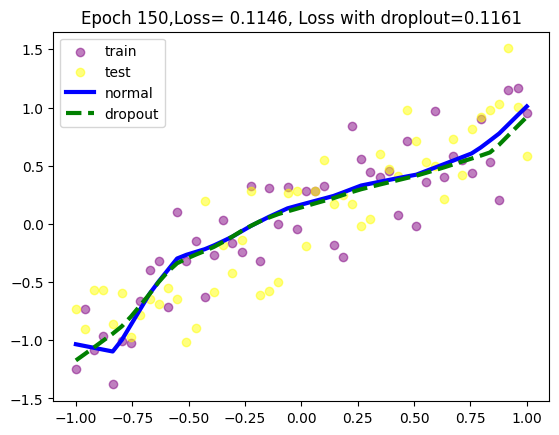

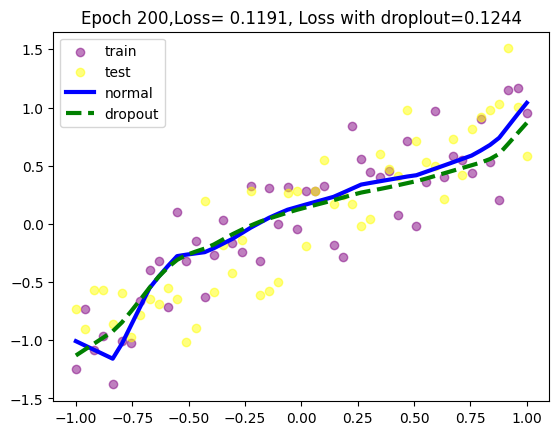

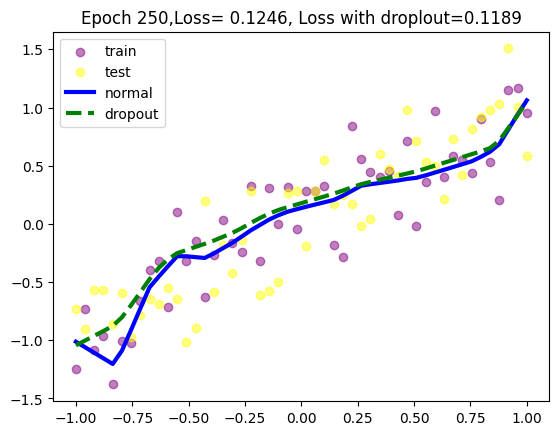

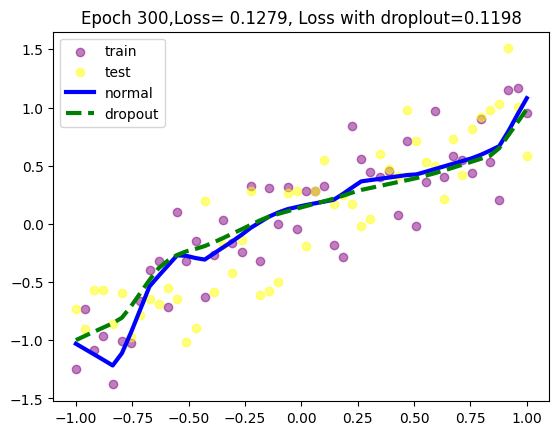

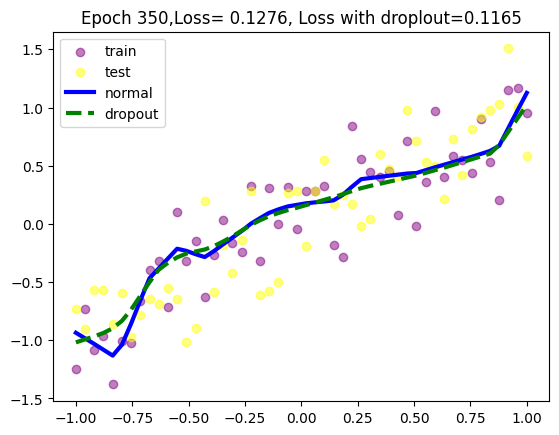

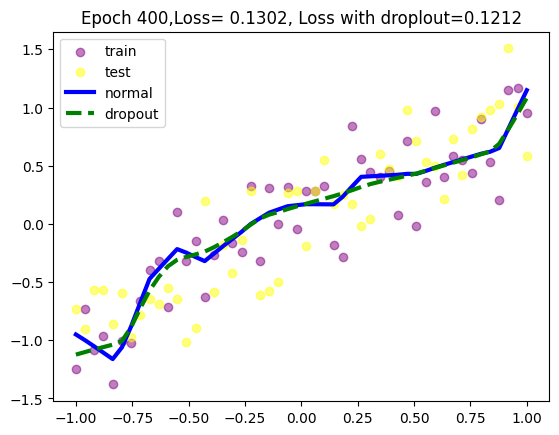

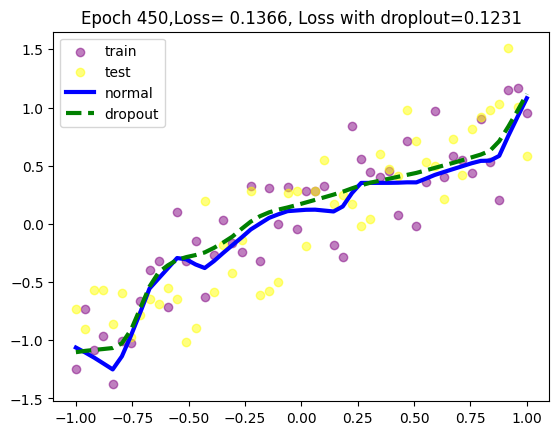

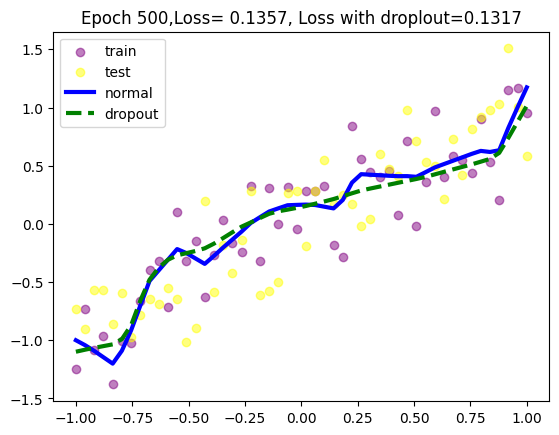

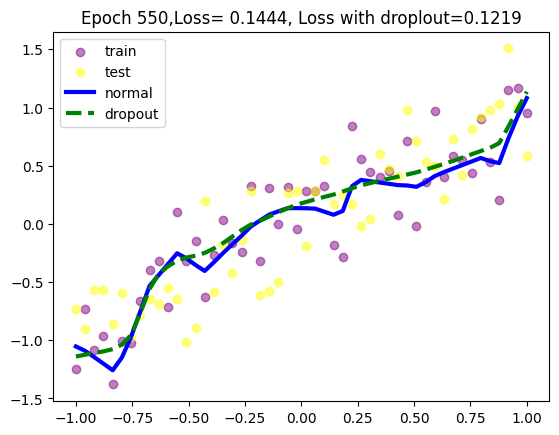

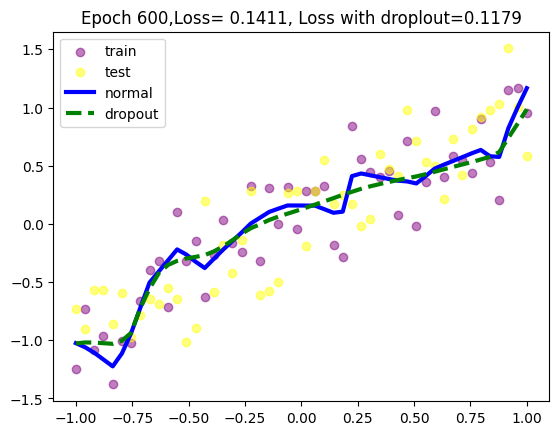

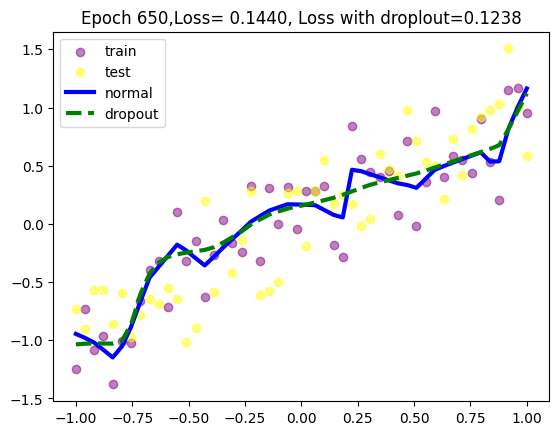

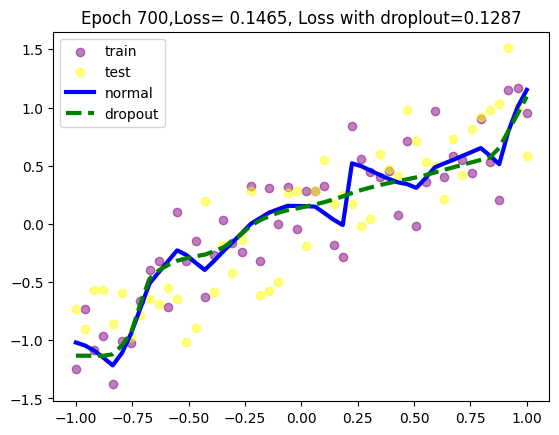

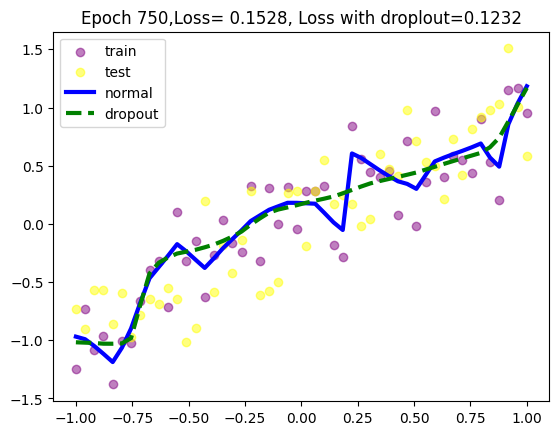

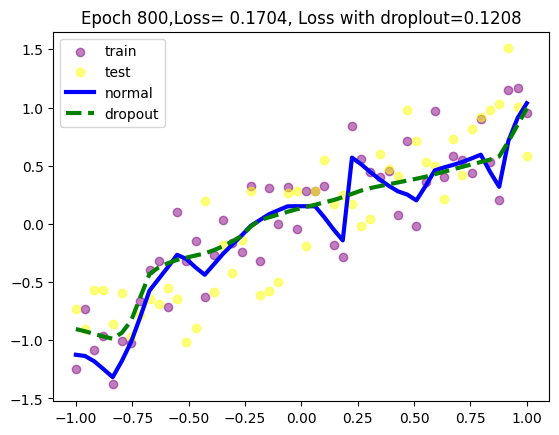

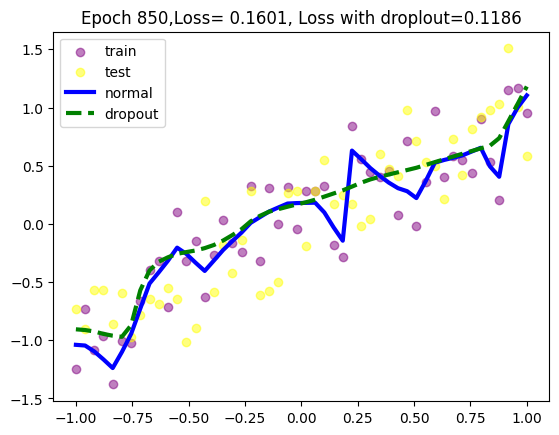

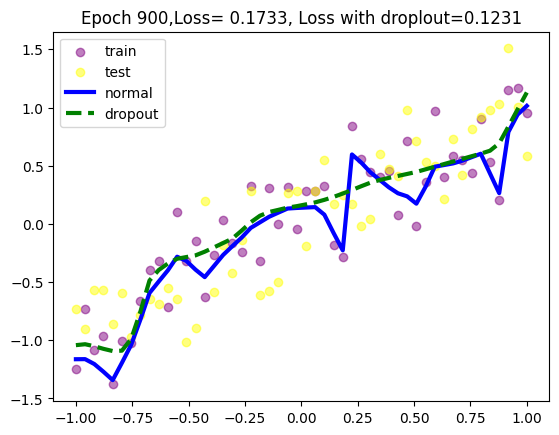

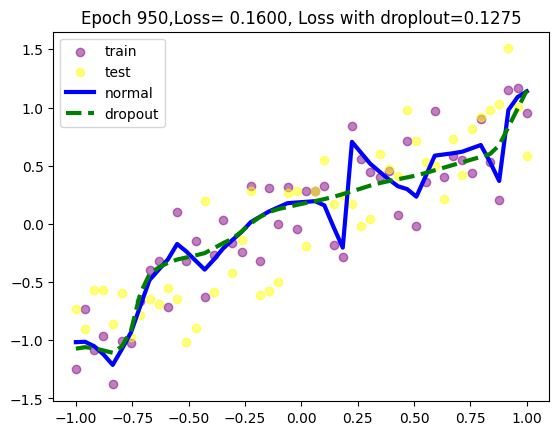

In [45]:
max_epochs=1000
for epoch in range(max_epochs):
  pred=model(x_train)
  loss=loss_fn(pred,y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()
  pred_dropout=model_dropout(x_train)
  loss_dropout=loss_fn(pred_dropout,y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch %50==0:
    model.eval()
    model_dropout.eval()
    test_pred=model(x_test)
    test_loss=loss_fn(test_pred,y_test)

    test_pred_dropout=model_dropout(x_test)
    test_loss_dropout=loss_fn(test_pred_dropout,y_test)

    plt.scatter(x_train.data.numpy(),y_train.data.numpy(),c='purple',
                alpha=0.5,label='train')
    plt.scatter(x_test.data.numpy(),y_test.data.numpy(),c='yellow',
                alpha=0.5,label='test')
    plt.plot(x_test.data.numpy(),test_pred.data.numpy(),'b-',lw=3,label='normal')
    plt.plot(x_test.data.numpy(),test_pred_dropout.data.numpy(),'g--',lw=3,label='dropout')
    plt.title('Epoch %d,Loss= %0.4f, Loss with droplout=%0.4f'%(epoch,test_loss,test_loss_dropout)  )

    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)



 드롭아웃을 적용했을 때의 오차가 더
낮은 것을 확인

훈련 횟수가 늘어날수록 파란색
실선은 가장자리의 자주색 점들을 찾아가고 있습나다. 문제는 자쩍 선이 훈련 데이터셋을 의미
한다는 것이고， 이것은 다른 의미로 과적합 현상을 보이고 있다는 것입나다. 과적합이 발생하는
모델은 훈련 데이터에 대한 정확도는 높을 수 있지만 새로운 데이터， 즉 검증 데이터나 태스트 데
이터에 대해서는 제대로 동작하지 않는 문제가 있습니다. 이와 같이 과적합 현상을 방지하기 위해
드롭아웃을 시용하며 초학객 점선 그래프에서는 과적합 현상이 발생하지 않는 것을 확인할 수 있
습니다.

## 조기 종료를 이용한 성능 최적화

In [46]:
import matplotlib
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [51]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])

])

val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

In [52]:
train_dataset=datasets.ImageFolder(root=r'/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/archive/train',transform=train_transform)

train_dataloader=torch.utils.data.DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataset=datasets.ImageFolder(root=r'/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/archive/test',transform=val_transform)
val_dataloader=torch.utils.data.DataLoader(val_dataset,batch_size=32,shuffle=True)

In [50]:
def resnet50(pretrained=True,requires_grad=False):
  model=models.resnet50(progress=True,pretrained=pretrained)
  if requires_grad==False:
    for param in model.parameters():
      param.requires_grad=False
  elif requires_grad==True:
    for param in model.parameters():
      param.requires_grad=True
  model.fc=nn.Linear(2048,2)
  return model

In [54]:
#학습률 감소
class LRscheduler():
  def __init__(
      self,optimizer,patience=5,min_lr=1e-6,factor=0.5):
    self.optimizer=optimizer
    self.patience=patience
    self.min_lr=min_lr
    self.factor=factor
    self.lr_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        self.optimizer,
        mode='min',
        patience=self.patience,
        factor=self.factor,
        min_lr=self.min_lr,
        verbose=True
    )
  def __call__(self,val_loss):
    self.lr_scheduler.step(val_loss)

In [56]:
from os import path
from math import inf
class EarlyStopping():
  def __init__(self,patience=5,verbose=False,delta=0,
               path='/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/archive'):
    self.patience=patience
    self.verbose=verbose
    self.counter=0
    self.best_score=None
    self.early_stop=False
    self.val_loss_min=np.Inf
    self.delta=delta
    self.path=path

  def __call__(self, val_loss,model):
    score=-val_loss
    if self.best_score is None:
      self.best_score=score
      self.save_checkpoint(val_loss,model)
    elif score<self.best_score+self.delta:
      self.counter+=1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter>=self.patience:
        self.early_stop=True
    else:
      self.best_score=score
      self.save_checkpoint(val_loss,model)
      self.counter=0
  def save_checkpoint(self,val_loss,model):
    if self.verbose:
      print(f'Validation loss decresed({self.val_loss_min:.6f}-->{val_loss:.6f}). Saving model ...')
      torch.save(model.state_dict(),self.path)
      self.val_loss_min=val_loss


In [58]:
parser=argparse.ArgumentParser()
parser.add_argument('--lr-scheduler',dest='lr_scheduler',action='store_true')
parser.add_argument('--early-stopping',dest='early_stopping',action='store_true')
args, unknown = parser.parse_known_args()

args = vars(args)

In [59]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 101.6 MB/s eta 0:00:00


In [60]:
print(f'computation device: {device}\n')
model=models.resnet50(pretrained=True).to(device)
total_params=sum(p.numel() for p in model.parameters())
print(f'{total_params:,} total parameters' )
total_trainable_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} trainable parameters')

computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]


25,557,032 total parameters
25,557,032 trainable parameters


In [70]:
lr=0.001
epochs=10
optimizer=optim.Adam(model.parameters(),lr=lr)
criterion=nn.CrossEntropyLoss()

In [62]:
loss_plot_name='loss'
acc_plot_name='accuracy'
model_name='model'

In [63]:
if args['lr_scheduler']:
  print('Info: Initializing learing rate scheduler')
  lr_scheduler=LRscheduler
  loss_plot_name='lrs_loss'
  acc_plot_name='lrs_accuracy'
  model_name='lrs_model'
if args['early_stopping']:
  print('Info: Initializing early stopping')
  early_stopping=EarlyStopping()
  loss_plot_name='es_loss'
  acc_plot_name='es_accuracy'
  model_name='es_model'


In [64]:
def training(model,train_dataloader,train_dataset,optimizer,criterion):
  print('Training')
  model.train()
  train_running_loss=0.0
  train_running_correct=0
  counter=0
  total=0
  prog_bar=tqdm(enumerate(train_dataloader),total=int(len(train_dataset)/
                                                      train_dataloader.batch_size))
  for i, data in prog_bar:
    counter+=1
    data,target=data[0].to(device),data[1].to(device)
    total+=target.size(0)
    optimizer.zero_grad()
    outputs=model(data)
    loss=criterion(outputs,target)
    train_running_loss+=loss.item()
    _,preds=torch.max(outputs.data,1)
    train_running_correct+=(preds==target).sum().item()
    loss.backward()
    optimizer.step()
  train_loss=train_running_loss/counter
  train_accuracy=100.*train_running_correct/total
  return train_loss,train_accuracy

In [73]:
def validate(model, val_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0
    total = 0

    prog_bar = tqdm(
        enumerate(val_dataloader),
        total=len(val_dataloader)
    )

    with torch.no_grad():
        for i, data in prog_bar:
            counter += 1

            data, target = data[0].to(device), data[1].to(device)
            total += target.size(0)

            outputs = model(data)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()

            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total

    return val_loss, val_accuracy


In [74]:
train_loss,train_accuracy=[],[]
val_loss,val_accuracy=[],[]
start=time.time()

for epoch in range(epochs):
  print(f'Epoch {epoch+1} of {epochs}')
  train_epoch_loss,train_epoch_accuracy=training(
      model,train_dataloader,train_dataset,optimizer,criterion)
  val_epoch_loss,val_epoch_accuracy=validate(
      model,val_dataloader,val_dataset,criterion)
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss,model)
    if early_stopping.early_stop:
      break
  print(f'Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}')
  print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}')
end=time.time()
print(f'Training time: {(end-start)/60:.3f} minutes')

Epoch 1 of 10
Training


16it [00:05,  2.71it/s]


Validating


100%|██████████| 16/16 [05:58<00:00, 22.39s/it]


Train Loss: 0.6743, Train Acc: 65.86
Val Loss: 1.8655, Val Acc: 54.20
Epoch 2 of 10
Training


...

Train Loss: 0.3761, Train Acc: 83.13
Val Loss: 0.7062, Val Acc: 72.00
Epoch 10 of 10
Training


16it [00:05,  2.94it/s]


Validating


100%|██████████| 16/16 [00:05<00:00,  2.92it/s]

Train Loss: 0.3377, Train Acc: 84.54
Val Loss: 0.6840, Val Acc: 72.40
Training time: 7.698 minutes


Saving loss and accuracy plots


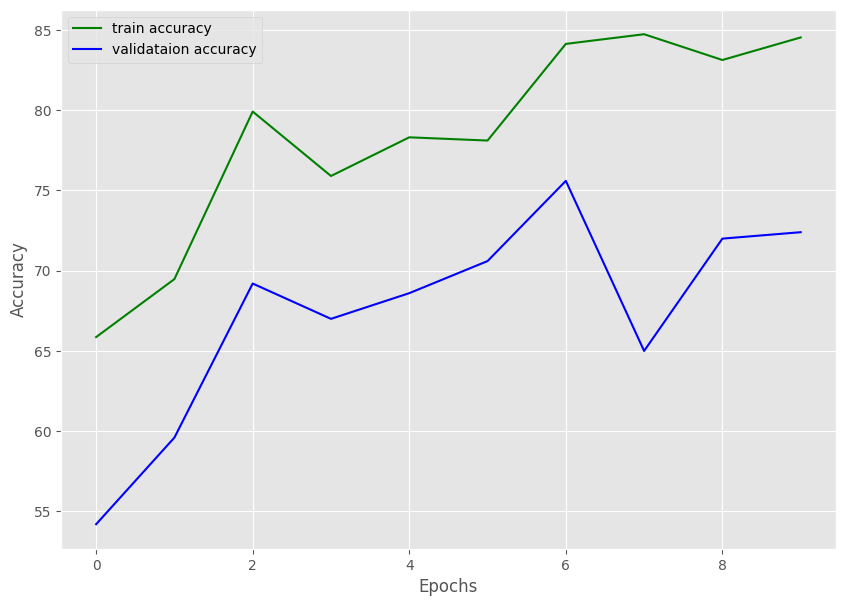

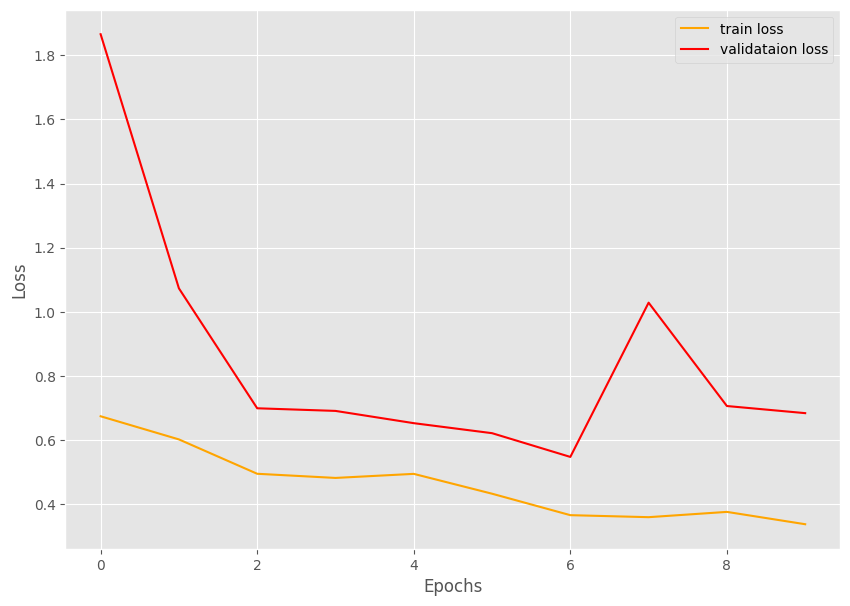

Saving model ...
Training Complete


In [75]:
print('Saving loss and accuracy plots')
plt.figure(figsize=(10,7))
plt.plot(train_accuracy,color='green',label='train accuracy')
plt.plot(val_accuracy,color='blue',label='validataion accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'{acc_plot_name}.png')
plt.show()
plt.figure(figsize=(10,7))
plt.plot(train_loss,color='orange',label='train loss')
plt.plot(val_loss,color='red',label='validataion loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'{loss_plot_name}.png')
plt.show()

print('Saving model ...')
torch.save(model.state_dict(), f'{model_name}.pth')
print('Training Complete')